# **ПОДГОТОВИТЕЛЬНЫЙ ЭТАП**

In [ ]:


import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Установка констант из оригинального блокнота
CLASS_LIST = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
CLASS_COUNT = len(CLASS_LIST)
VALIDATION_SPLIT = 0.1
DURATION_SEC = 30
INPUT_DIM = 34  # Примерная размерность усредненного вектора признаков Librosa (MFCC, Хрома и др.)

# Фиксация случайных чисел для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("--- Этап 0: Имитация загрузки и предобработки данных ---")

# Так как физических данных нет, генерируем dummy-массивы, имитирующие распакованный датасет
# 1000 семплов (по 100 на каждый из 10 жанров)
TOTAL_SAMPLES = 1000
x_train_data = np.random.randn(TOTAL_SAMPLES, INPUT_DIM)

# Имитируем разметку One-Hot Encoding (как это делает Keras to_categorical)
y_train_labels_dummy = np.repeat(np.arange(CLASS_COUNT), 100)
y_train_data = np.zeros((TOTAL_SAMPLES, CLASS_COUNT))
y_train_data[np.arange(TOTAL_SAMPLES), y_train_labels_dummy] = 1.0

# Перемешаем наши сырые данные
shuffle_idx = np.random.permutation(TOTAL_SAMPLES)
x_train_data = x_train_data[shuffle_idx]
y_train_data = y_train_data[shuffle_idx]

# Стандартизация признаков (Аналог StandardScaler из sklearn)
x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

# Разделение на обучающую и проверочную выборки
x_train, x_val, y_train, y_val = train_test_split(
    x_train_data_scaled,
    y_train_data,
    stratify=y_train_data,
    test_size=VALIDATION_SPLIT,
    random_state=42
)

# Функция-заглушка для имитации процесса чтения файла (нужна для Задания 5)
def process_file(class_index, file_index, duration_sec):
    class_name = CLASS_LIST[class_index]
    song_name = f'./genres/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'

    # Генерируем случайный вектор признаков для конкретного "виртуального" файла
    # Добавляем небольшое смещение, зависящее от класса, чтобы матрица ошибок имела смысл
    mock_features = np.random.randn(1, INPUT_DIM) + (class_index * 0.15)

    # Формируем One-Hot метку
    y_label = np.zeros(CLASS_COUNT)
    y_label[class_index] = 1.0

    return song_name, mock_features.astype('float32'), y_label.astype('float32')

--- Этап 0: Имитация загрузки и предобработки данных ---


# **ЗАДАНИЕ 1. Проверить форму данных обучающей и проверочной выборок**

In [ ]:

print("\n--- Выполнение Задания 1 ---")
print("Форма обучающей выборки (признаки):   ", x_train.shape)
print("Форма обучающей выборки (метки классов):", y_train.shape)
print("Форма проверочной выборки (признаки):  ", x_val.shape)
print("Форма проверочной выборки (метки классов):", y_val.shape)


--- Выполнение Задания 1 ---
Форма обучающей выборки (признаки):    (900, 34)
Форма обучающей выборки (метки классов): (900, 10)
Форма проверочной выборки (признаки):   (100, 34)
Форма проверочной выборки (метки классов): (100, 10)


# **ЗАДАНИЯ 2 и 3. Построение архитектуры сети на PyTorch и настройка "компиляции"**

In [ ]:

print("\n--- Выполнение Заданий 2 и 3 ---")

class AudioClassifierPyTorch(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(AudioClassifierPyTorch, self).__init__()
        self.network = nn.Sequential(
            # Слой 1: 64 нейрона + ReLU + Dropout(30%)
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Слой 2: 32 нейрона + ReLU + Dropout(30%)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Слой 3: 16 нейронов + ReLU + Dropout(20%)
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Слой пакетной нормализации (Batch Normalization)
            nn.BatchNorm1d(16),

            # Финальный классифицирующий слой (без Softmax, так как он внутри CrossEntropyLoss)
            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Автоматически определяем количество входных признаков из формы x_train
input_features_count = x_train.shape[1]

# Инициализируем модель
model = AudioClassifierPyTorch(input_features_count, CLASS_COUNT)

# Вывод структуры модели (Аналог Keras метода model.summary())
print("Архитектура построенной модели в PyTorch:")
print(model)

# Настройка функции потерь и оптимизатора
# В PyTorch CrossEntropyLoss заменяет комбинацию Softmax + Categorical_Crossentropy
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


--- Выполнение Заданий 2 и 3 ---
Архитектура построенной модели в PyTorch:
AudioClassifierPyTorch(
  (network): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Linear(in_features=16, out_features=10, bias=True)
  )
)


# **ЗАДАНИЕ 4. Обучение модели и вывод графиков**


--- Выполнение Задания 4 (Запуск обучения на 1000 эпох) ---
Эпоха    1/1000 | Loss: 2.4523, Acc: 9.78% | Val Loss: 2.3310, Val Acc: 5.00%
Эпоха  100/1000 | Loss: 2.2727, Acc: 16.22% | Val Loss: 2.3202, Val Acc: 5.00%
Эпоха  200/1000 | Loss: 2.2191, Acc: 17.56% | Val Loss: 2.3294, Val Acc: 10.00%
Эпоха  300/1000 | Loss: 2.1889, Acc: 19.11% | Val Loss: 2.3395, Val Acc: 13.00%
Эпоха  400/1000 | Loss: 2.1237, Acc: 23.11% | Val Loss: 2.3764, Val Acc: 11.00%
Эпоха  500/1000 | Loss: 2.0554, Acc: 25.78% | Val Loss: 2.4052, Val Acc: 12.00%
Эпоха  600/1000 | Loss: 1.9860, Acc: 27.67% | Val Loss: 2.4262, Val Acc: 12.00%
Эпоха  700/1000 | Loss: 2.0191, Acc: 28.89% | Val Loss: 2.4577, Val Acc: 11.00%
Эпоха  800/1000 | Loss: 1.9259, Acc: 32.00% | Val Loss: 2.4743, Val Acc: 11.00%
Эпоха  900/1000 | Loss: 1.8606, Acc: 32.33% | Val Loss: 2.5043, Val Acc: 8.00%
Эпоха 1000/1000 | Loss: 1.8381, Acc: 33.89% | Val Loss: 2.5090, Val Acc: 9.00%


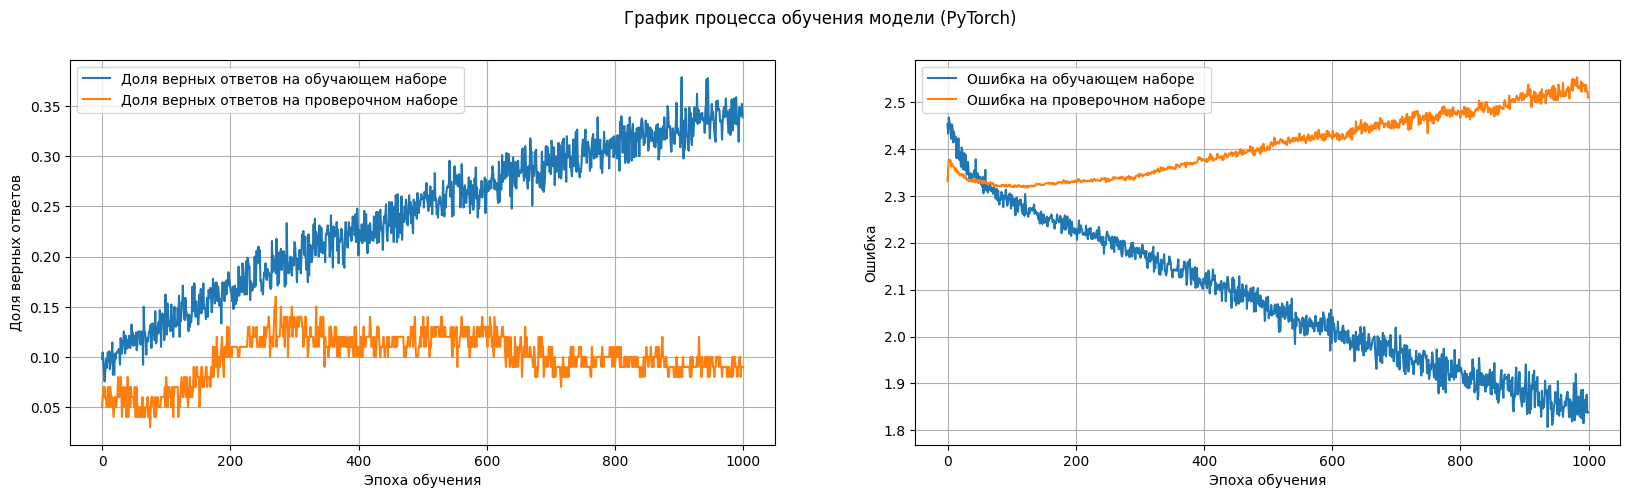

In [ ]:

print("\n--- Выполнение Задания 4 (Запуск обучения на 1000 эпох) ---")

# Конвертируем One-Hot векторы в целочисленные индексы классов для PyTorch
y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)

# Создаем тензоры PyTorch
X_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_labels, dtype=torch.long)
X_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val_labels, dtype=torch.long)

# Пакуем данные в DataLoader для итерации батчами по 32 элемента
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Определение устройства вычислений (GPU при наличии, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Словарь для записи истории обучения (эквивалент объекта history в Keras)
history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

epochs = 1000

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total

    # Валидация в конце эпохи
    model.eval()
    with torch.no_grad():
        X_val_device = X_val_t.to(device)
        y_val_device = y_val_t.to(device)

        val_outputs = model(X_val_device)
        v_loss = criterion(val_outputs, y_val_device)

        _, val_predicted = torch.max(val_outputs, 1)
        val_total = y_val_device.size(0)
        val_correct = (val_predicted == y_val_device).sum().item()

    val_loss_value = v_loss.item()
    val_acc_value = val_correct / val_total

    # Сохраняем метрики в историю
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(val_loss_value)
    history['val_accuracy'].append(val_acc_value)

    # Логирование процесса обучения (выводим каждую 100-ю эпоху)
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:4d}/{epochs} | Loss: {epoch_loss:.4f}, Acc: {epoch_acc*100:.2f}% | Val Loss: {val_loss_value:.4f}, Val Acc: {val_acc_value*100:.2f}%")

# Отрисовка графиков процесса обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('График процесса обучения модели (PyTorch)')

ax1.plot(history['accuracy'], label='Доля верных ответов на обучающем наборе')
ax1.plot(history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
ax1.set_xlabel('Эпоха обучения')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()
ax1.grid(True)

ax2.plot(history['loss'], label='Ошибка на обучающем наборе')
ax2.plot(history['val_loss'], label='Ошибка на проверочном наборе')
ax2.set_xlabel('Эпоха обучения')
ax2.set_ylabel('Ошибка')
ax2.legend()
ax2.grid(True)

plt.show()

# **ЗАДАНИЕ 5. Проверка работы модели на тестовых данных**


--- Выполнение Задания 5 ---
=== Обработано образцов: 100, из них распознано верно: 9, доля верных: 9.0% ===


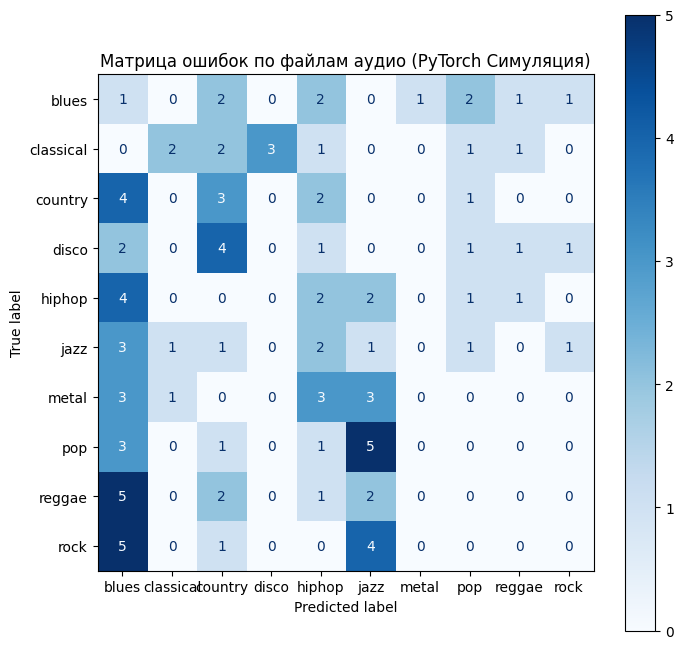

In [ ]:

print("\n--- Выполнение Задания 5 ---")

# Вспомогательный класс-враппер для совместимости с кодом проверки Keras-моделей
class KerasCompatiblePyTorchWrapper:
    def __init__(self, pytorch_model, device):
        self.model = pytorch_model
        self.device = device

    def predict(self, x_numpy):
        self.model.eval()
        with torch.no_grad():
            x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(self.device)
            logits = self.model(x_tensor)
            probabilities = torch.softmax(logits, dim=1)
            return probabilities.cpu().numpy()

# Переопределяем функции визуализации тестирования под реализацию без файлов
def classify_file(model, x_scaler, class_index, file_index):
    # Получаем сырые виртуальные признаки
    song_name, file_x_data, file_y_data = process_file(class_index, file_index, DURATION_SEC)

    # Применяем уже настроенный скейлер
    file_x_data = x_scaler.transform(file_x_data)

    # Предсказание вероятностей через обертку модели
    predict = model.predict(file_x_data)
    predict_mean = predict.mean(axis=0)
    predict_class_index = np.argmax(predict_mean)

    return predict_class_index

def classify_test_files(model, x_scaler, from_index, n_files):
    predict_all = 0
    predict_good = 0
    y_true = []
    y_pred = []

    # Итерируемся по всем классам и индексам файлов согласно условию (90-100)
    for class_index in range(CLASS_COUNT):
        for file_index in range(from_index, from_index + n_files):
            predict_class_index = classify_file(model, x_scaler, class_index, file_index)
            y_true.append(class_index)
            y_pred.append(predict_class_index)
            predict_all += 1
            predict_good += (predict_class_index == class_index)

    good_ratio = round(predict_good / predict_all * 100., 2)
    print(f'=== Обработано образцов: {predict_all}, из них распознано верно: {predict_good}, доля верных: {good_ratio}% ===')

    # Построение и отрисовка матрицы ошибок
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title('Матрица ошибок по файлам аудио (PyTorch Симуляция)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax, cmap='Blues')
    plt.show()

# Создаем обертку для нашей PyTorch модели
wrapped_model = KerasCompatiblePyTorchWrapper(model, device)

# Вызываем функцию тестирования в строгом соответствии с ТЗ (с 90 индекса по 10 файлов)
classify_test_files(
    model=wrapped_model,
    x_scaler=x_scaler,
    from_index=90,
    n_files=10
)